In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [6]:
# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 500
warnings.filterwarnings('ignore', category=FutureWarning)

# Ruta relativa al dataset
RAW_DATA_PATH = '../data/raw/cardio_train.csv'

In [7]:
# Cargar datos
try:
    df = pd.read_csv(RAW_DATA_PATH, sep=';')
    print("Dataset cargado correctamente.")
except FileNotFoundError:
    print("Error: No se encuentra el archivo. Verifica la ruta.")

# Vista preliminar
print(f"\nDimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
display(df.head(10))
print("\nTipos de datos:")
print(df.dtypes)

Dataset cargado correctamente.

Dimensiones: 70000 filas, 13 columnas


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0



Tipos de datos:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


Distribución de clases:
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


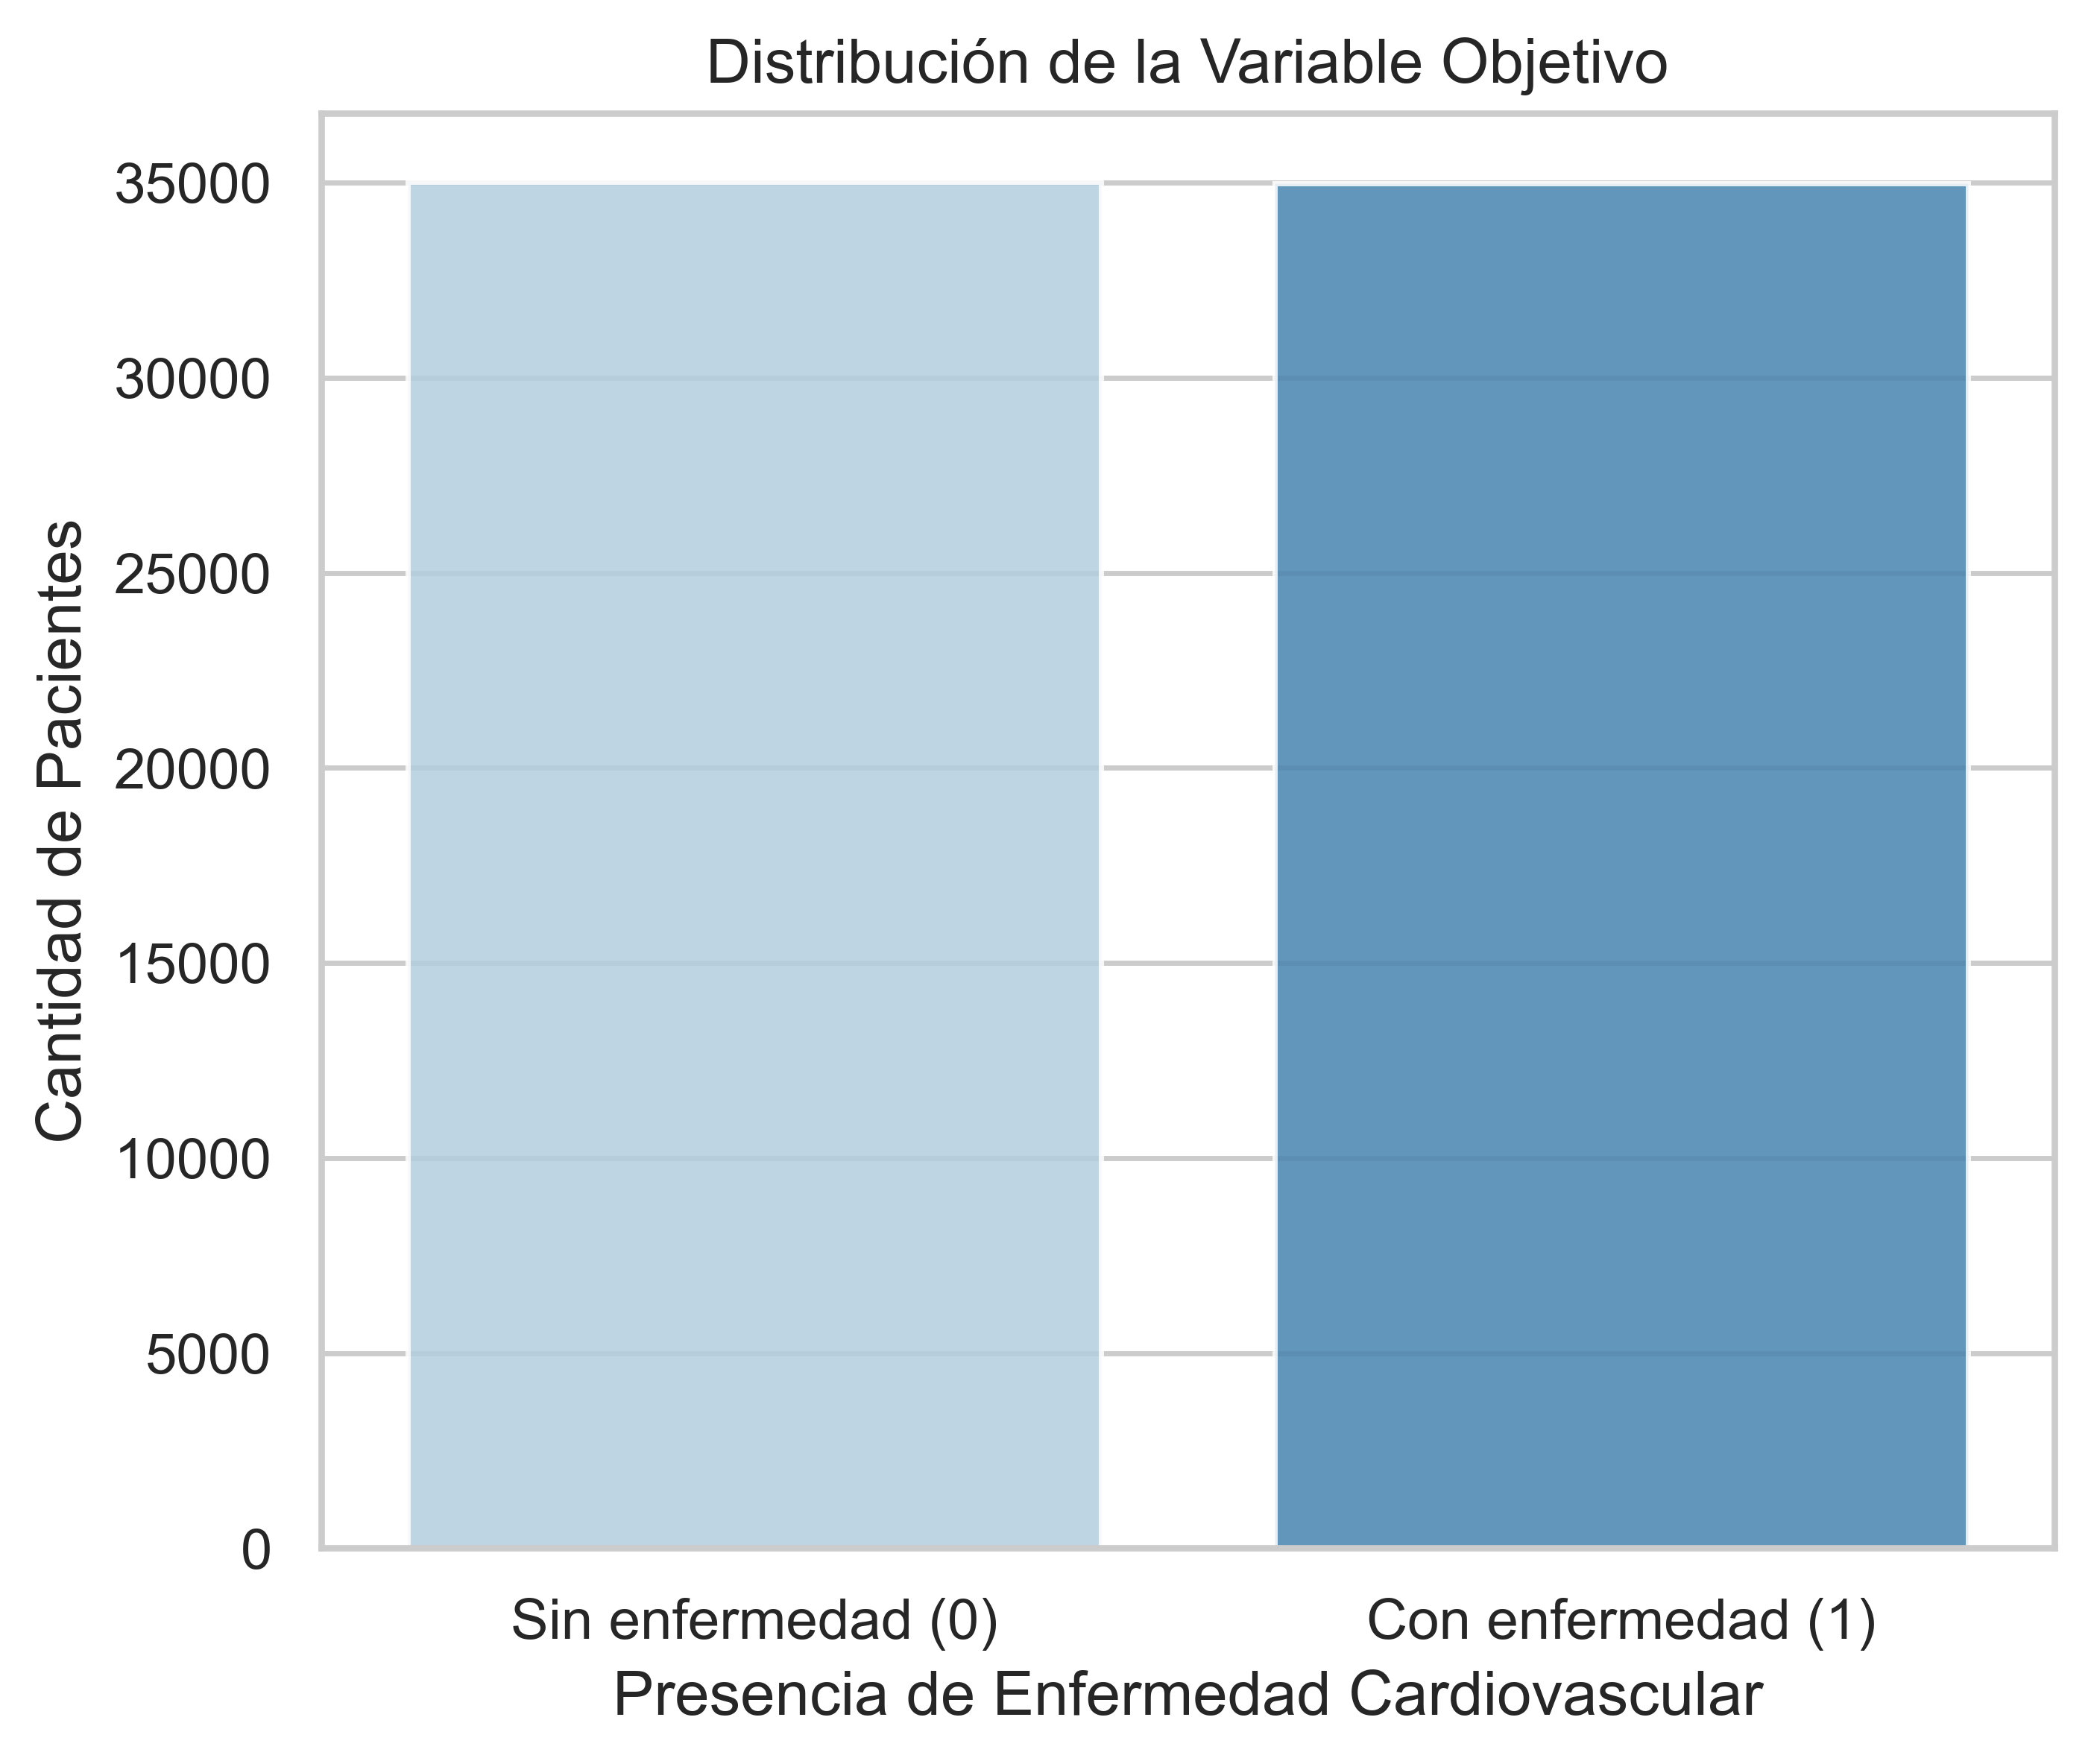

In [8]:
# Conteo de clases
conteo = df['cardio'].value_counts(normalize=True) * 100
print(f"Distribución de clases:\n{conteo}")

# Gráfico
plt.figure(figsize=(6, 5))
sns.countplot(x='cardio', data=df, palette='Blues', alpha=0.85)
plt.title('Distribución de la Variable Objetivo')
plt.xlabel('Presencia de Enfermedad Cardiovascular')
plt.ylabel('Cantidad de Pacientes')
plt.xticks([0, 1], ['Sin enfermedad (0)', 'Con enfermedad (1)'])
plt.show()

In [9]:
# Análisis Estadístico Descriptivo
print("\nEstadísticas Descriptivas:")
descripcion = df.describe().round(2)
display(descripcion)

# Nulos
nulos = df.isnull().sum().sum()
print(f"Total de valores nulos: {nulos}")

# Duplicados
duplicados = df.duplicated().sum()
print(f"Filas totalmente duplicadas: {duplicados}")


Estadísticas Descriptivas:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.0,70000.0
mean,49972.42,19468.87,1.35,164.36,74.21,128.82,96.63,1.37,1.23,0.09,0.05,0.8,0.5
std,28851.30,2467.25,0.48,8.21,14.40,154.01,188.47,0.68,0.57,0.28,0.23,0.4,0.5
min,0.00,10798.00,1.00,55.00,10.00,-150.00,-70.00,1.00,1.00,0.00,0.00,0.0,0.0
25%,25006.75,17664.00,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
50%,50001.50,19703.00,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
75%,74889.25,21327.00,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.0
max,99999.00,23713.00,2.00,250.00,200.00,16020.00,11000.00,3.00,3.00,1.00,1.00,1.0,1.0


Total de valores nulos: 0
Filas totalmente duplicadas: 0


In [10]:
# Definición de variables para análisis

df_plot = df.copy()
df_plot['age_years'] = (df_plot['age'] / 365).round(1)

variable_objetivo = 'cardio'
variables_numericas = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']
variables_categoricas = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
nombres_variables = {
    'age_years': 'Edad (años)',
    'height': 'Altura (cm)',
    'weight': 'Peso (kg)',
    'ap_hi': 'Presión Sistólica (mmHg)',
    'ap_lo': 'Presión Diastólica (mmHg)'
}

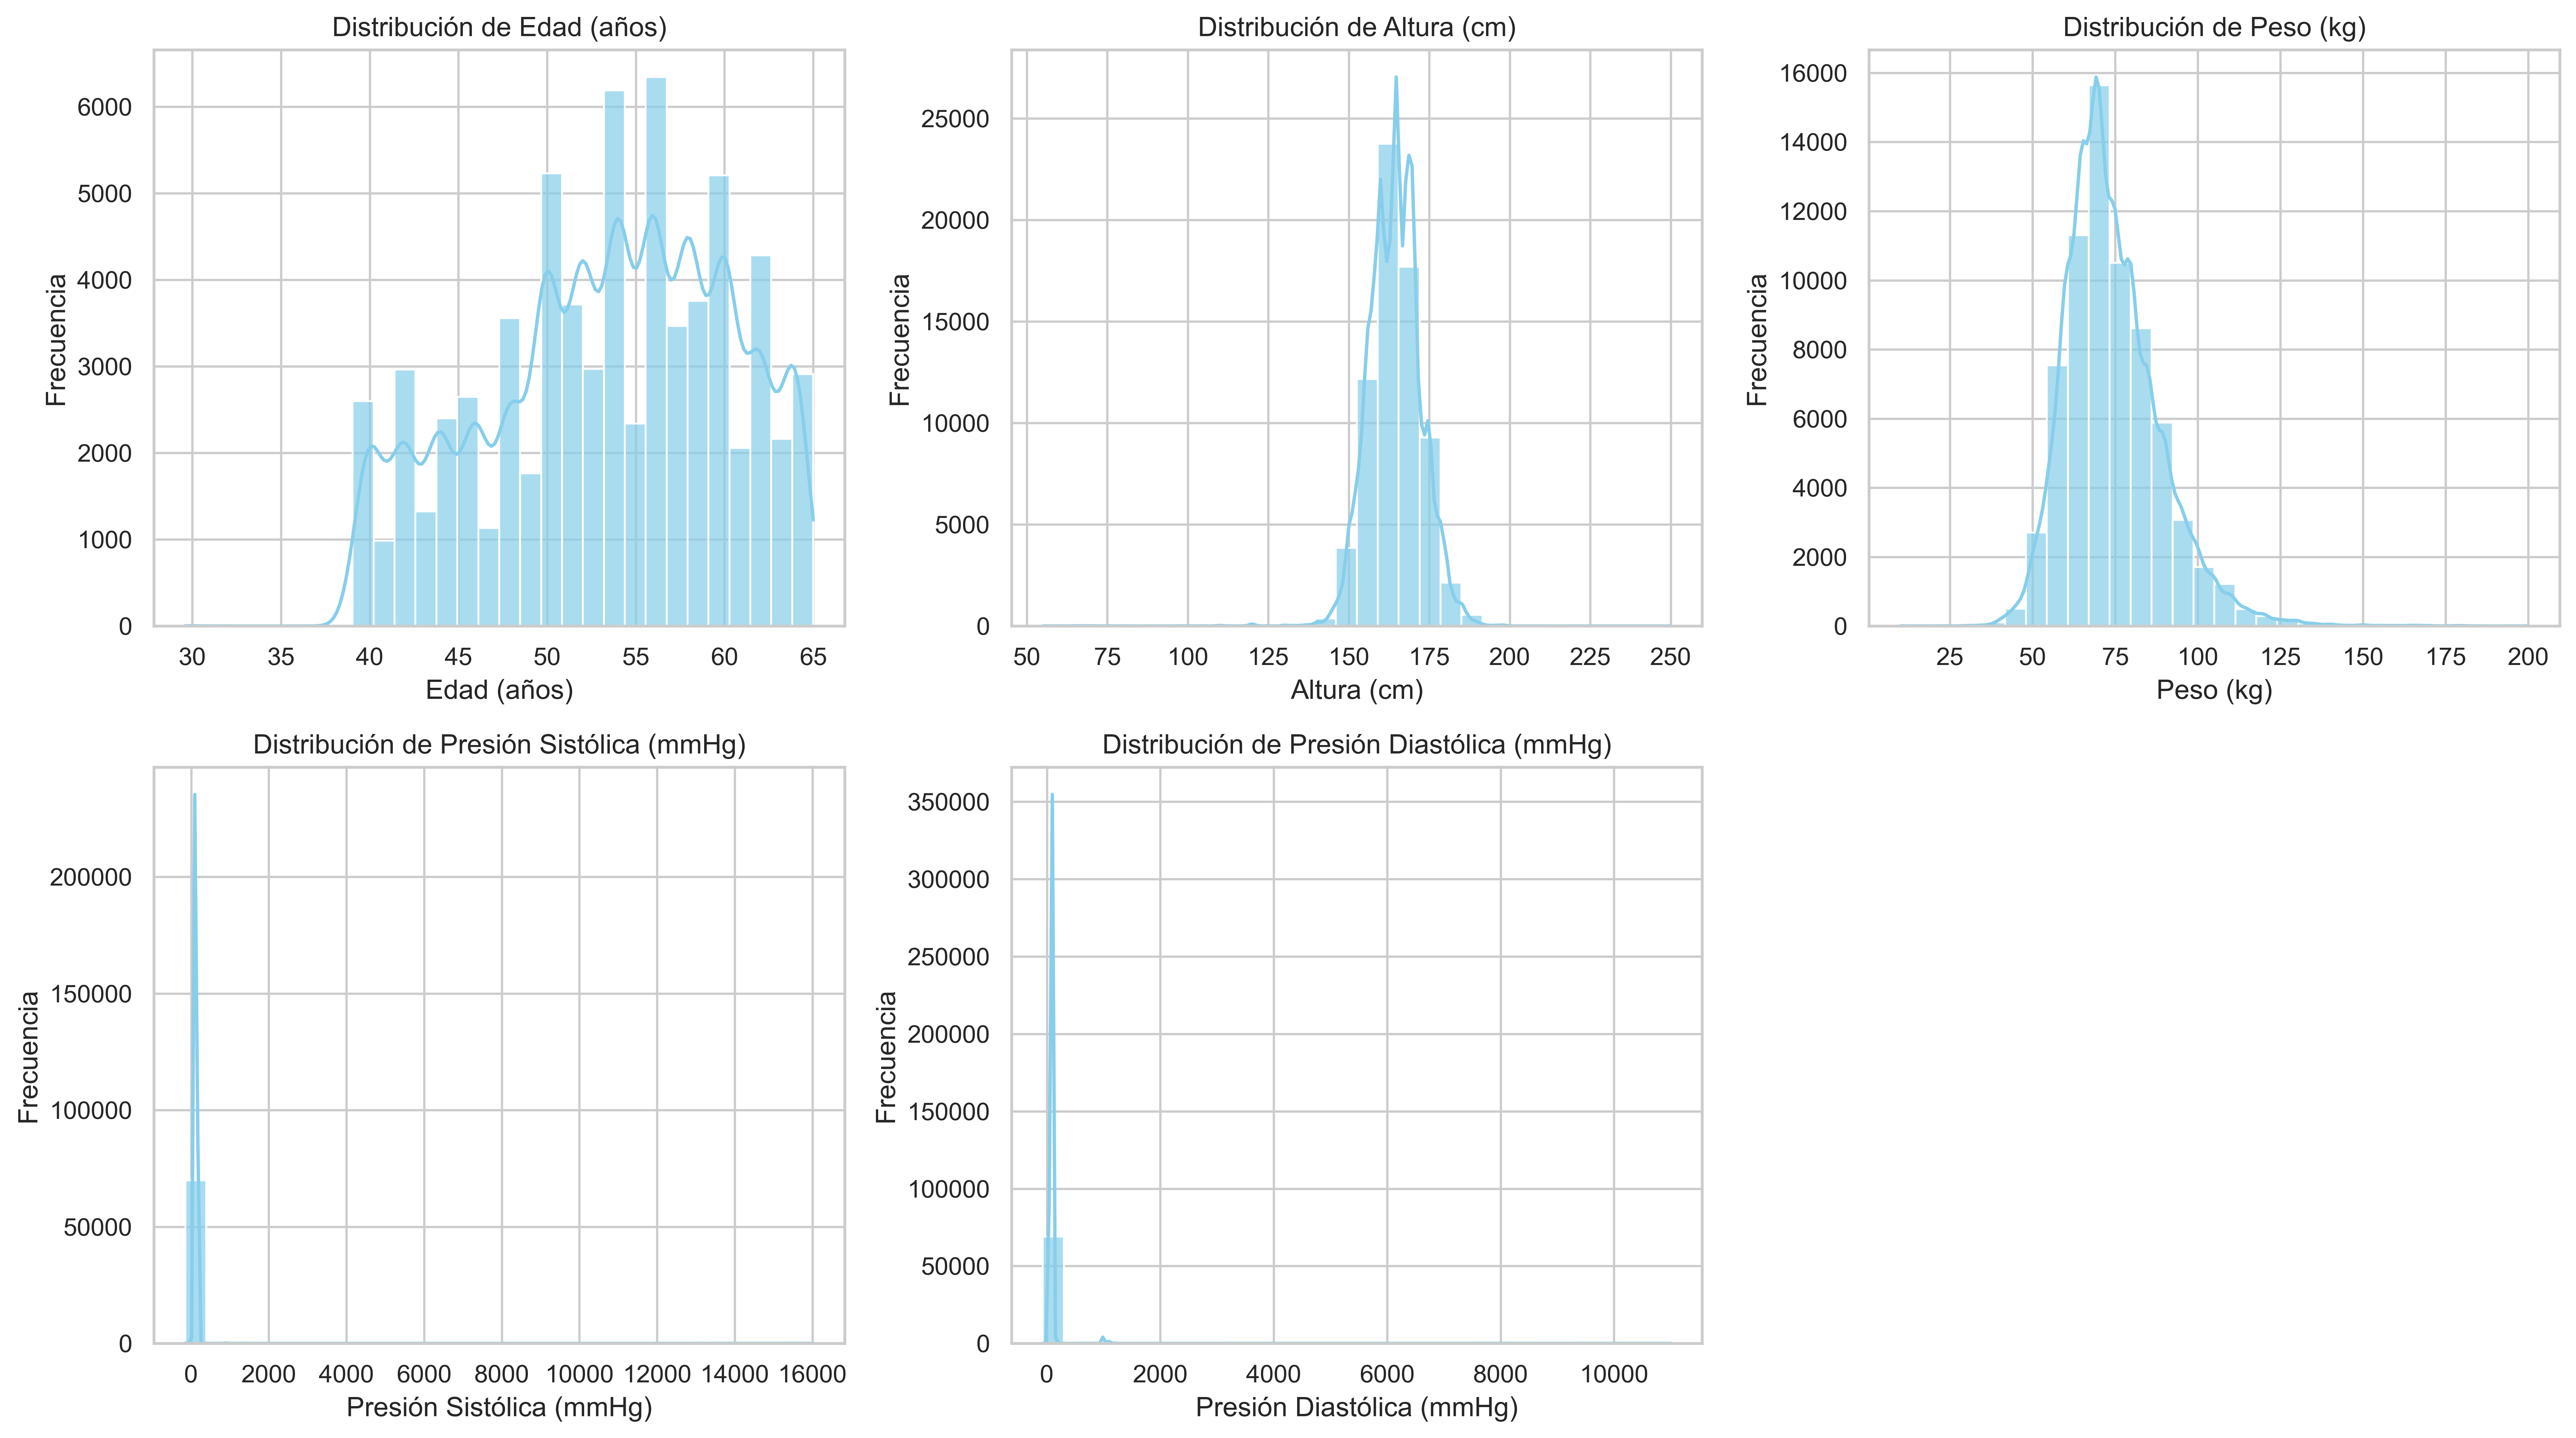

In [20]:
# Distribuciones de variables numéricas
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(variables_numericas):
    sns.histplot(df_plot[var], bins=30, kde=True, ax=axes[i], color='skyblue', alpha=0.7)
    axes[i].set_title(f'Distribución de {nombres_variables[var]}')
    axes[i].set_xlabel(nombres_variables[var])
    axes[i].set_ylabel('Frecuencia')

# Ocultar subplot sobrante
for j in range(len(variables_numericas), len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

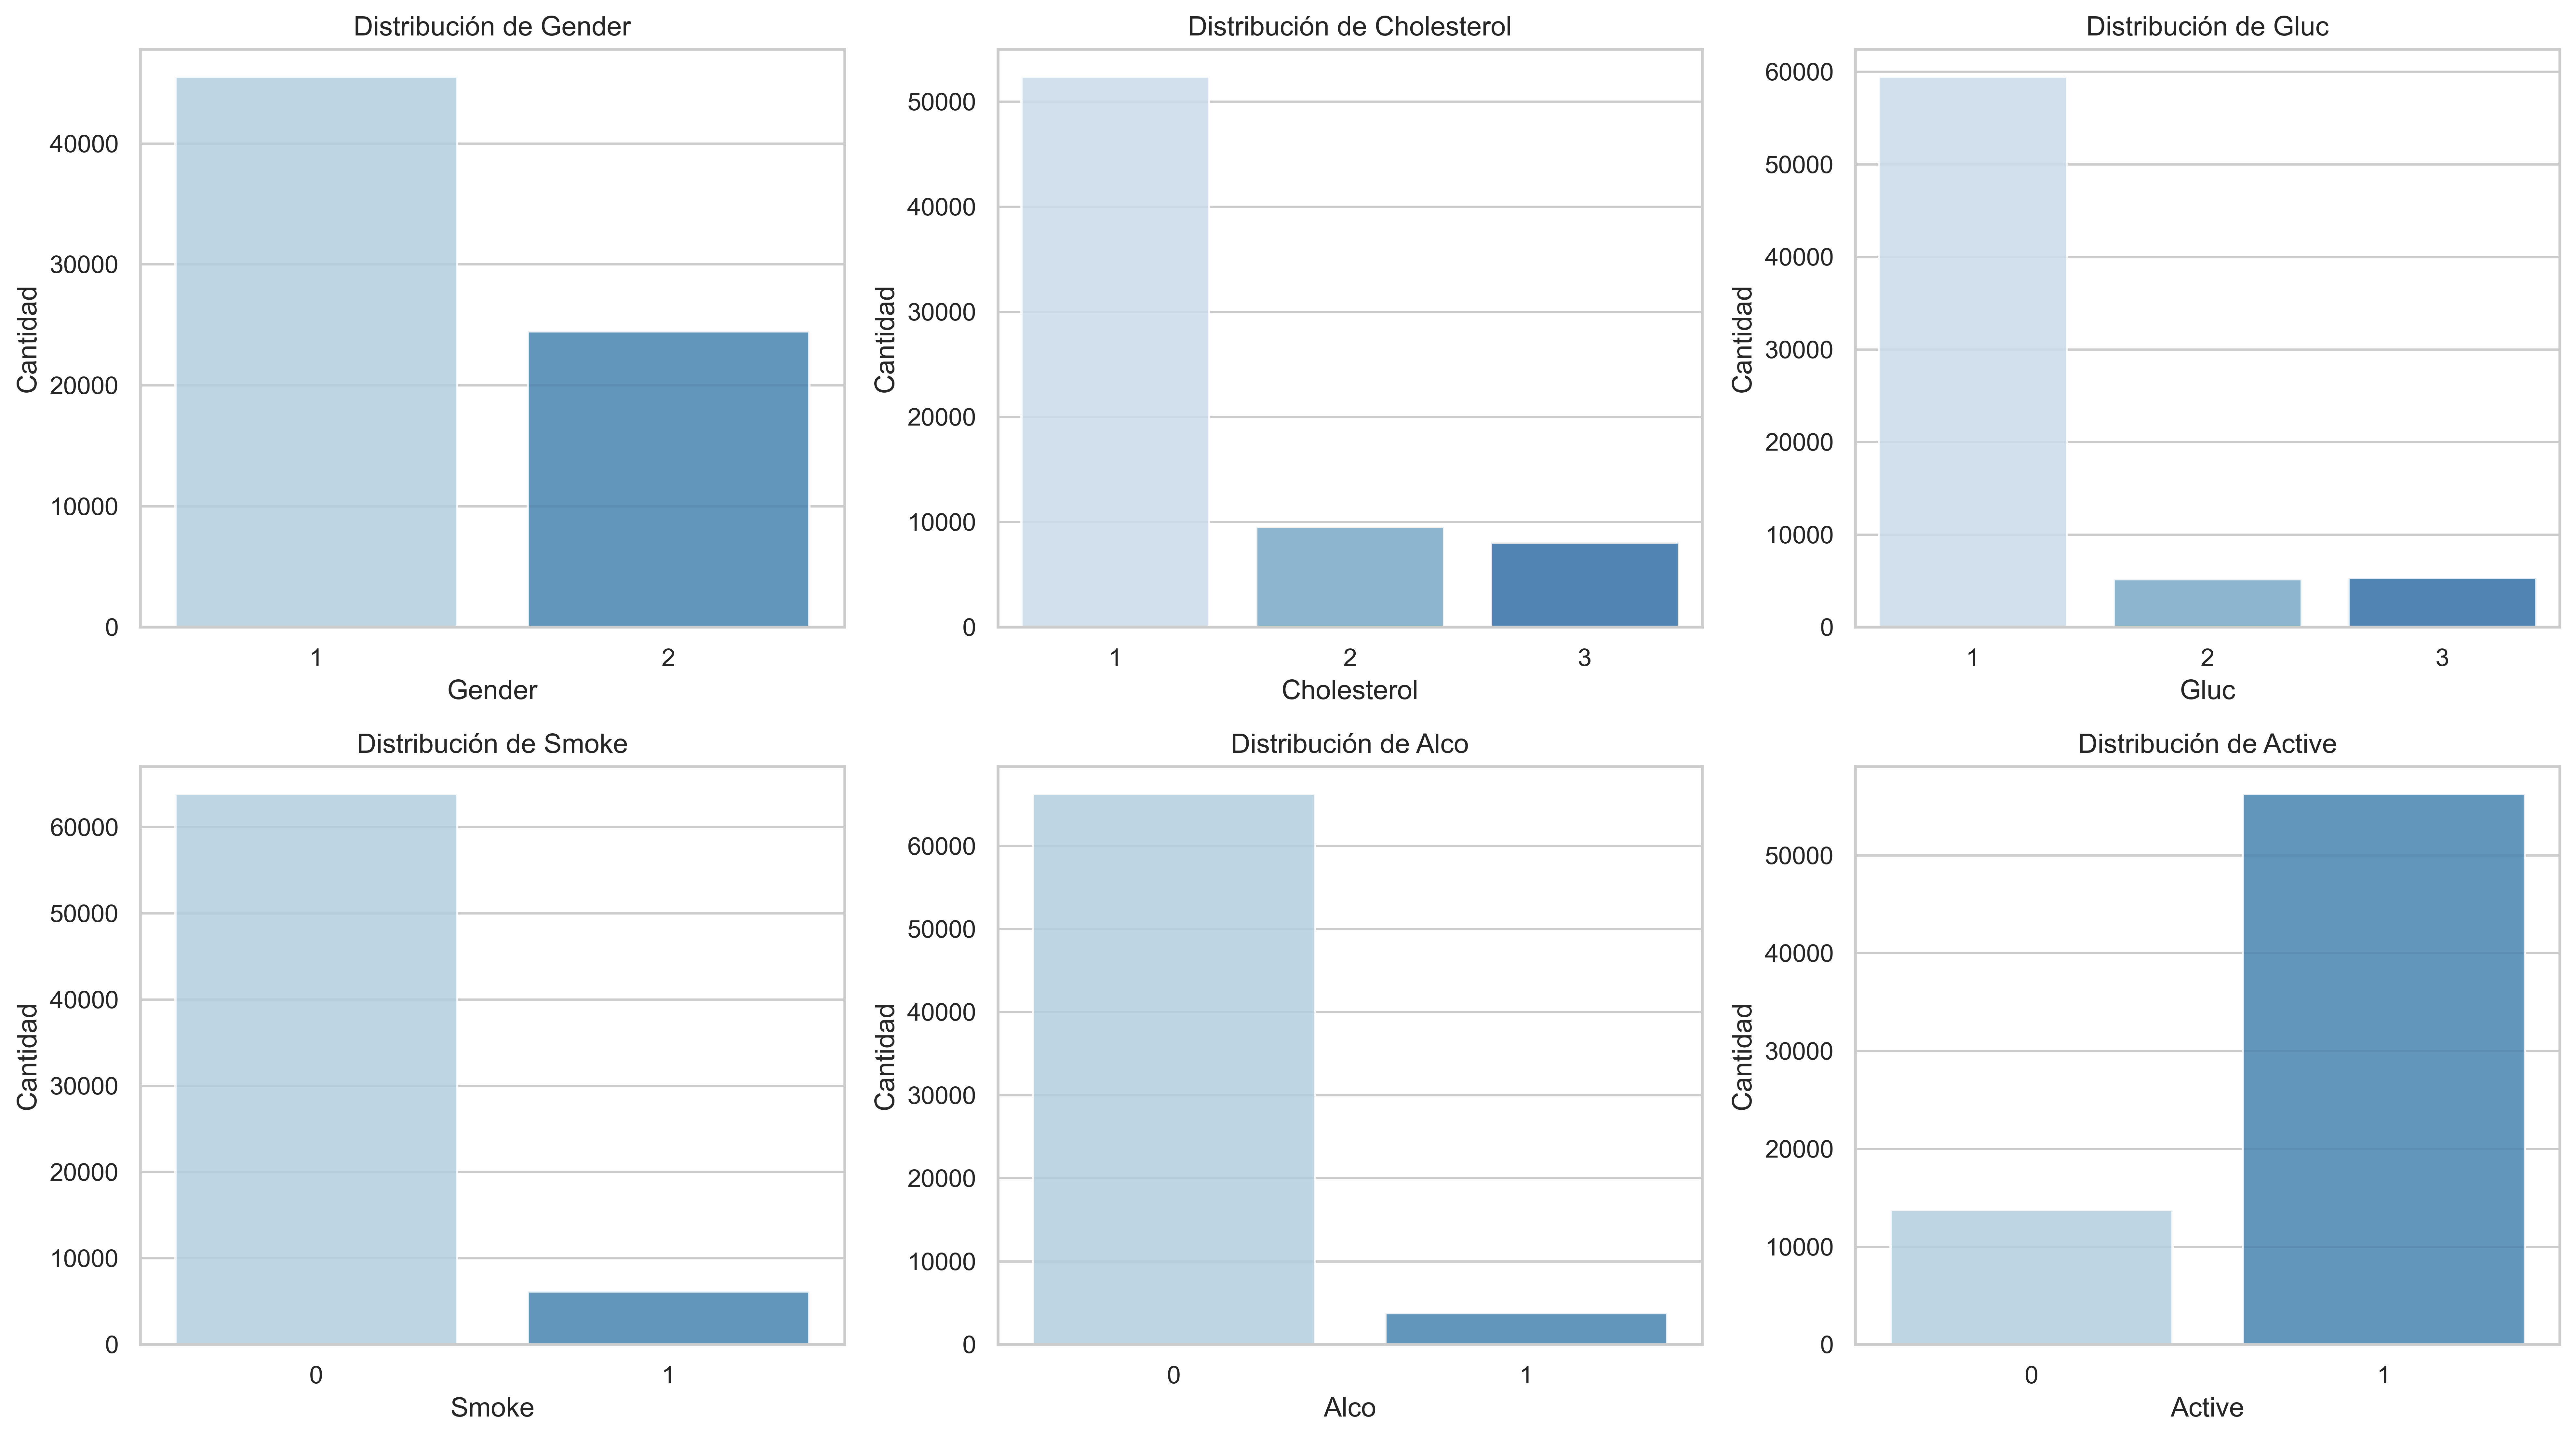

In [12]:
# Distribuciones de variables categoricas
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(variables_categoricas):
    sns.countplot(x=var, data=df_plot, ax=axes[i], palette='Blues', alpha=0.85)
    axes[i].set_title(f'Distribución de {var.capitalize()}')
    axes[i].set_xlabel(var.capitalize())
    axes[i].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()


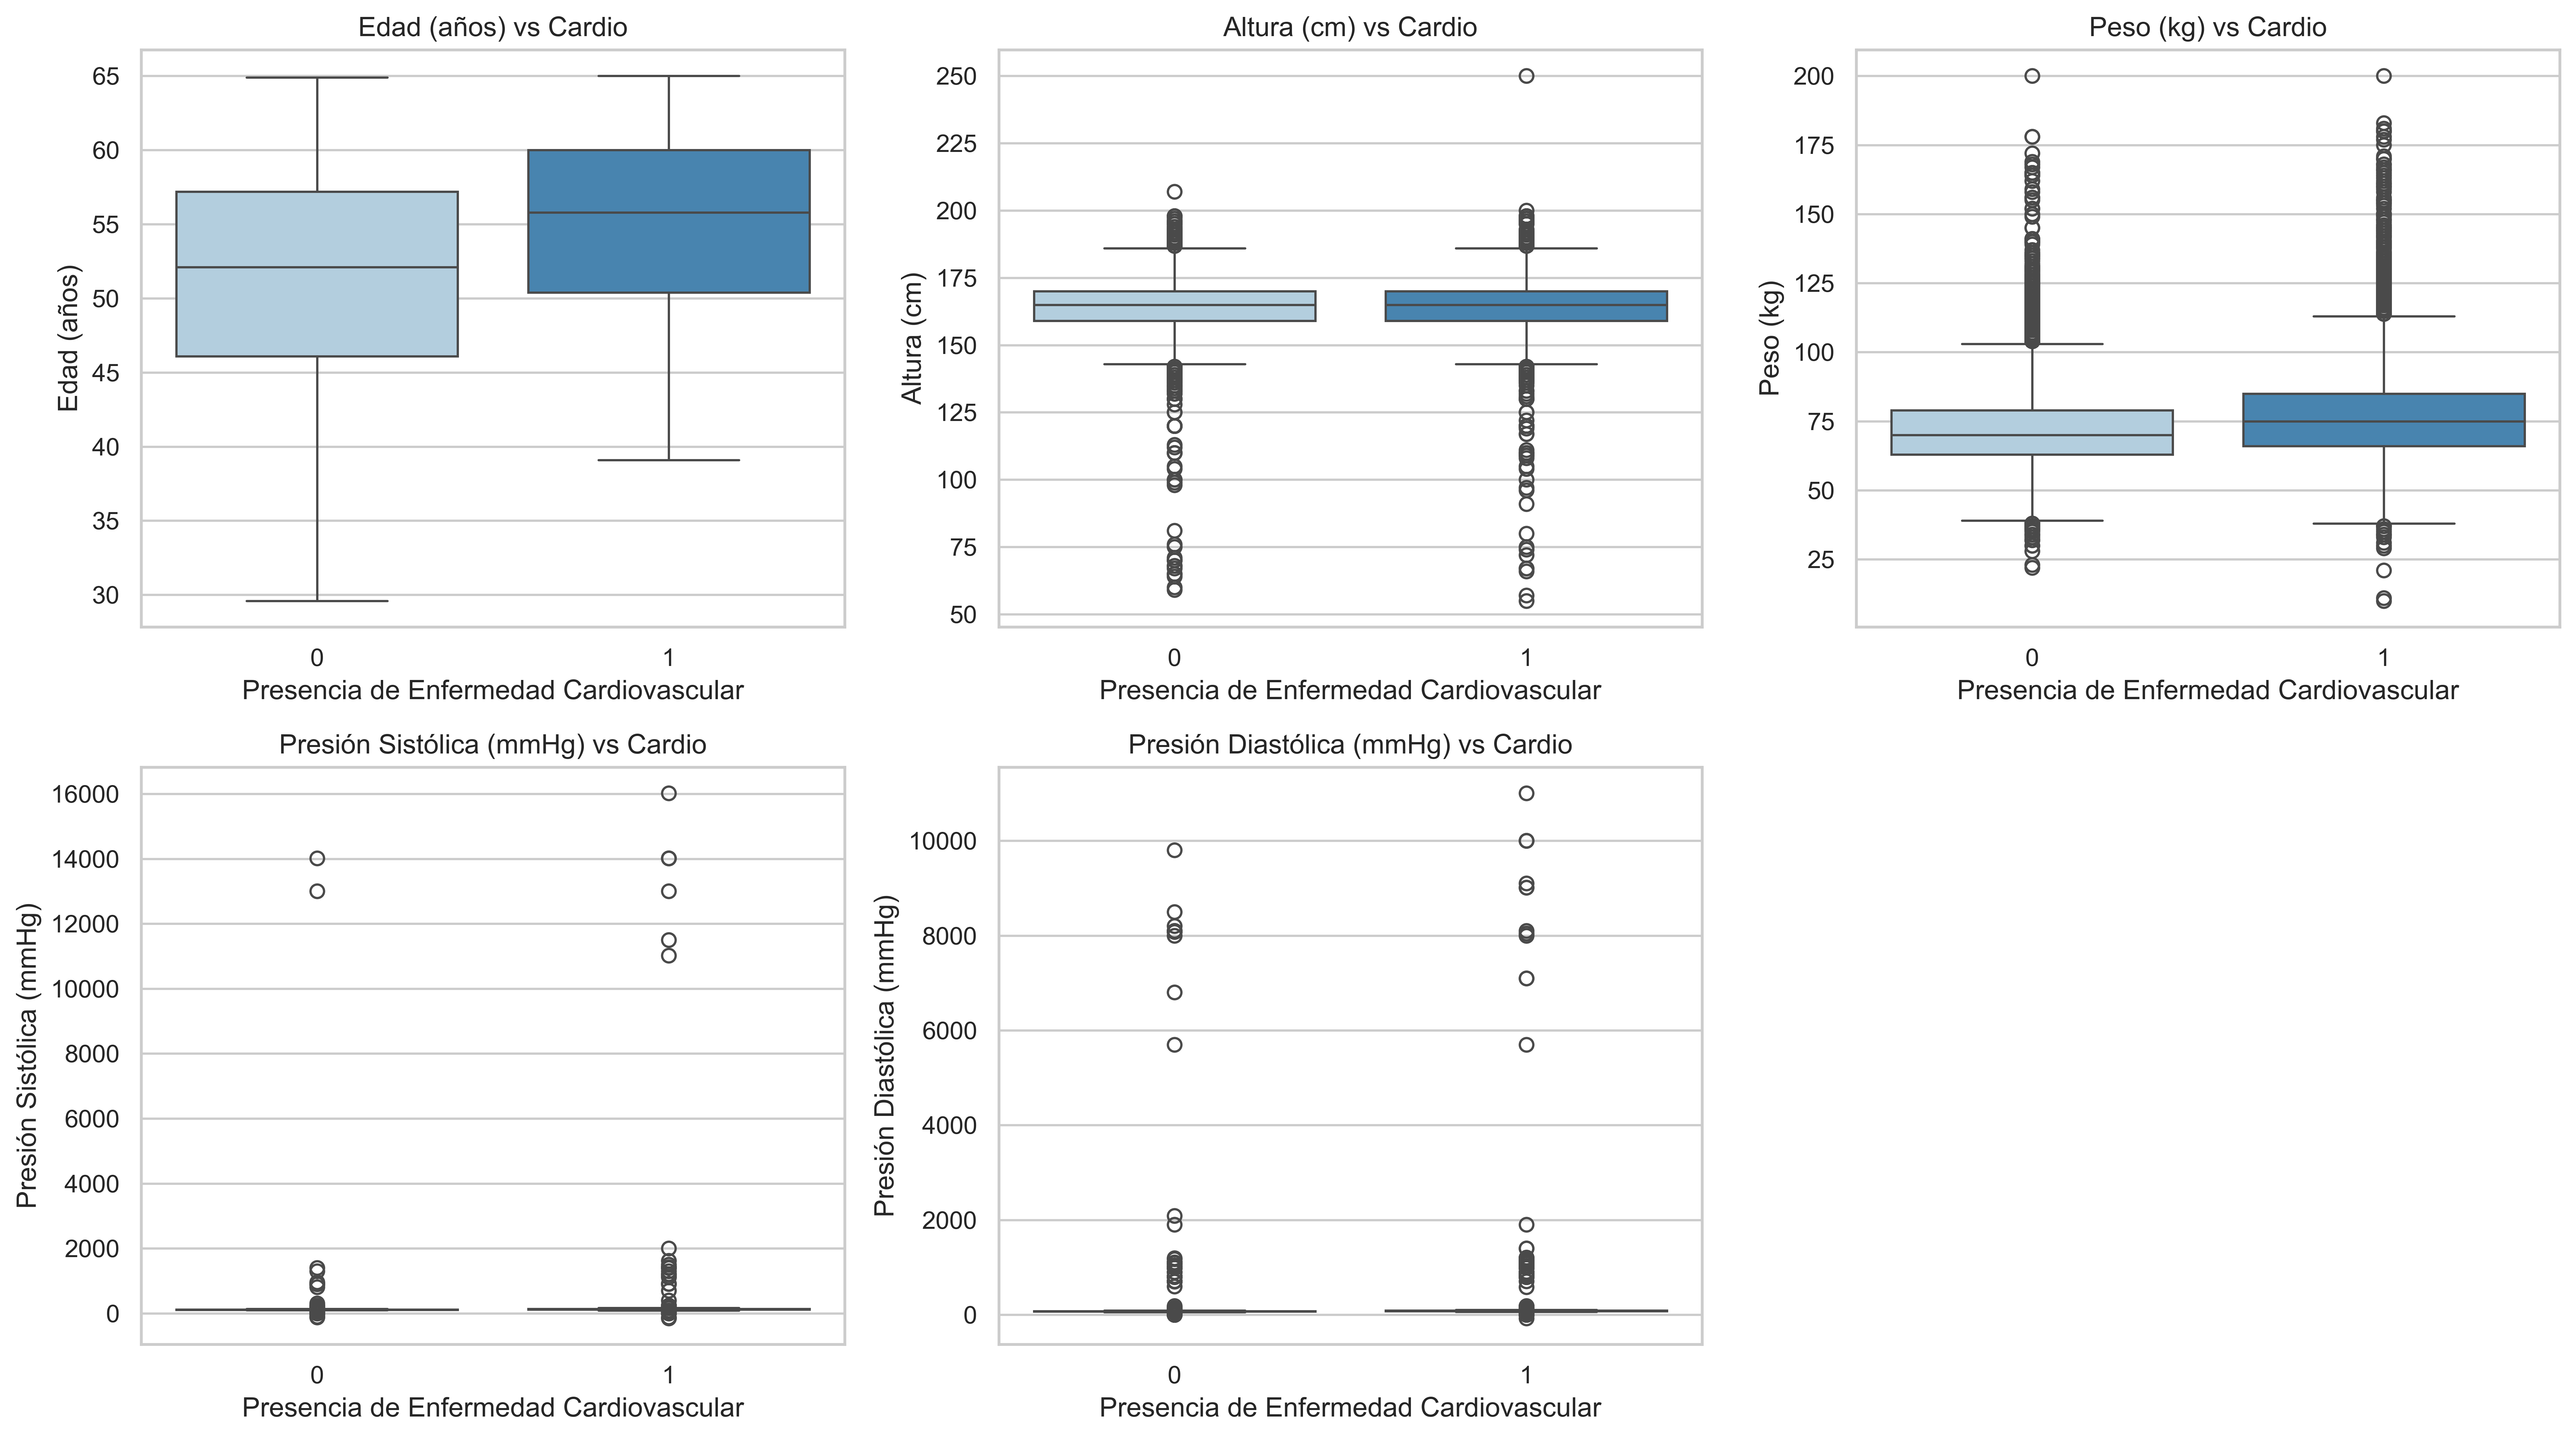

In [13]:
# Relación entre variables numéricas y la variable objetivo
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(variables_numericas):
    sns.boxplot(x=variable_objetivo, y=var, data=df_plot, ax=axes[i], palette='Blues')
    axes[i].set_title(f'{nombres_variables[var]} vs {variable_objetivo.capitalize()}')
    axes[i].set_xlabel('Presencia de Enfermedad Cardiovascular')
    axes[i].set_ylabel(nombres_variables[var])

for j in range(len(variables_numericas), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

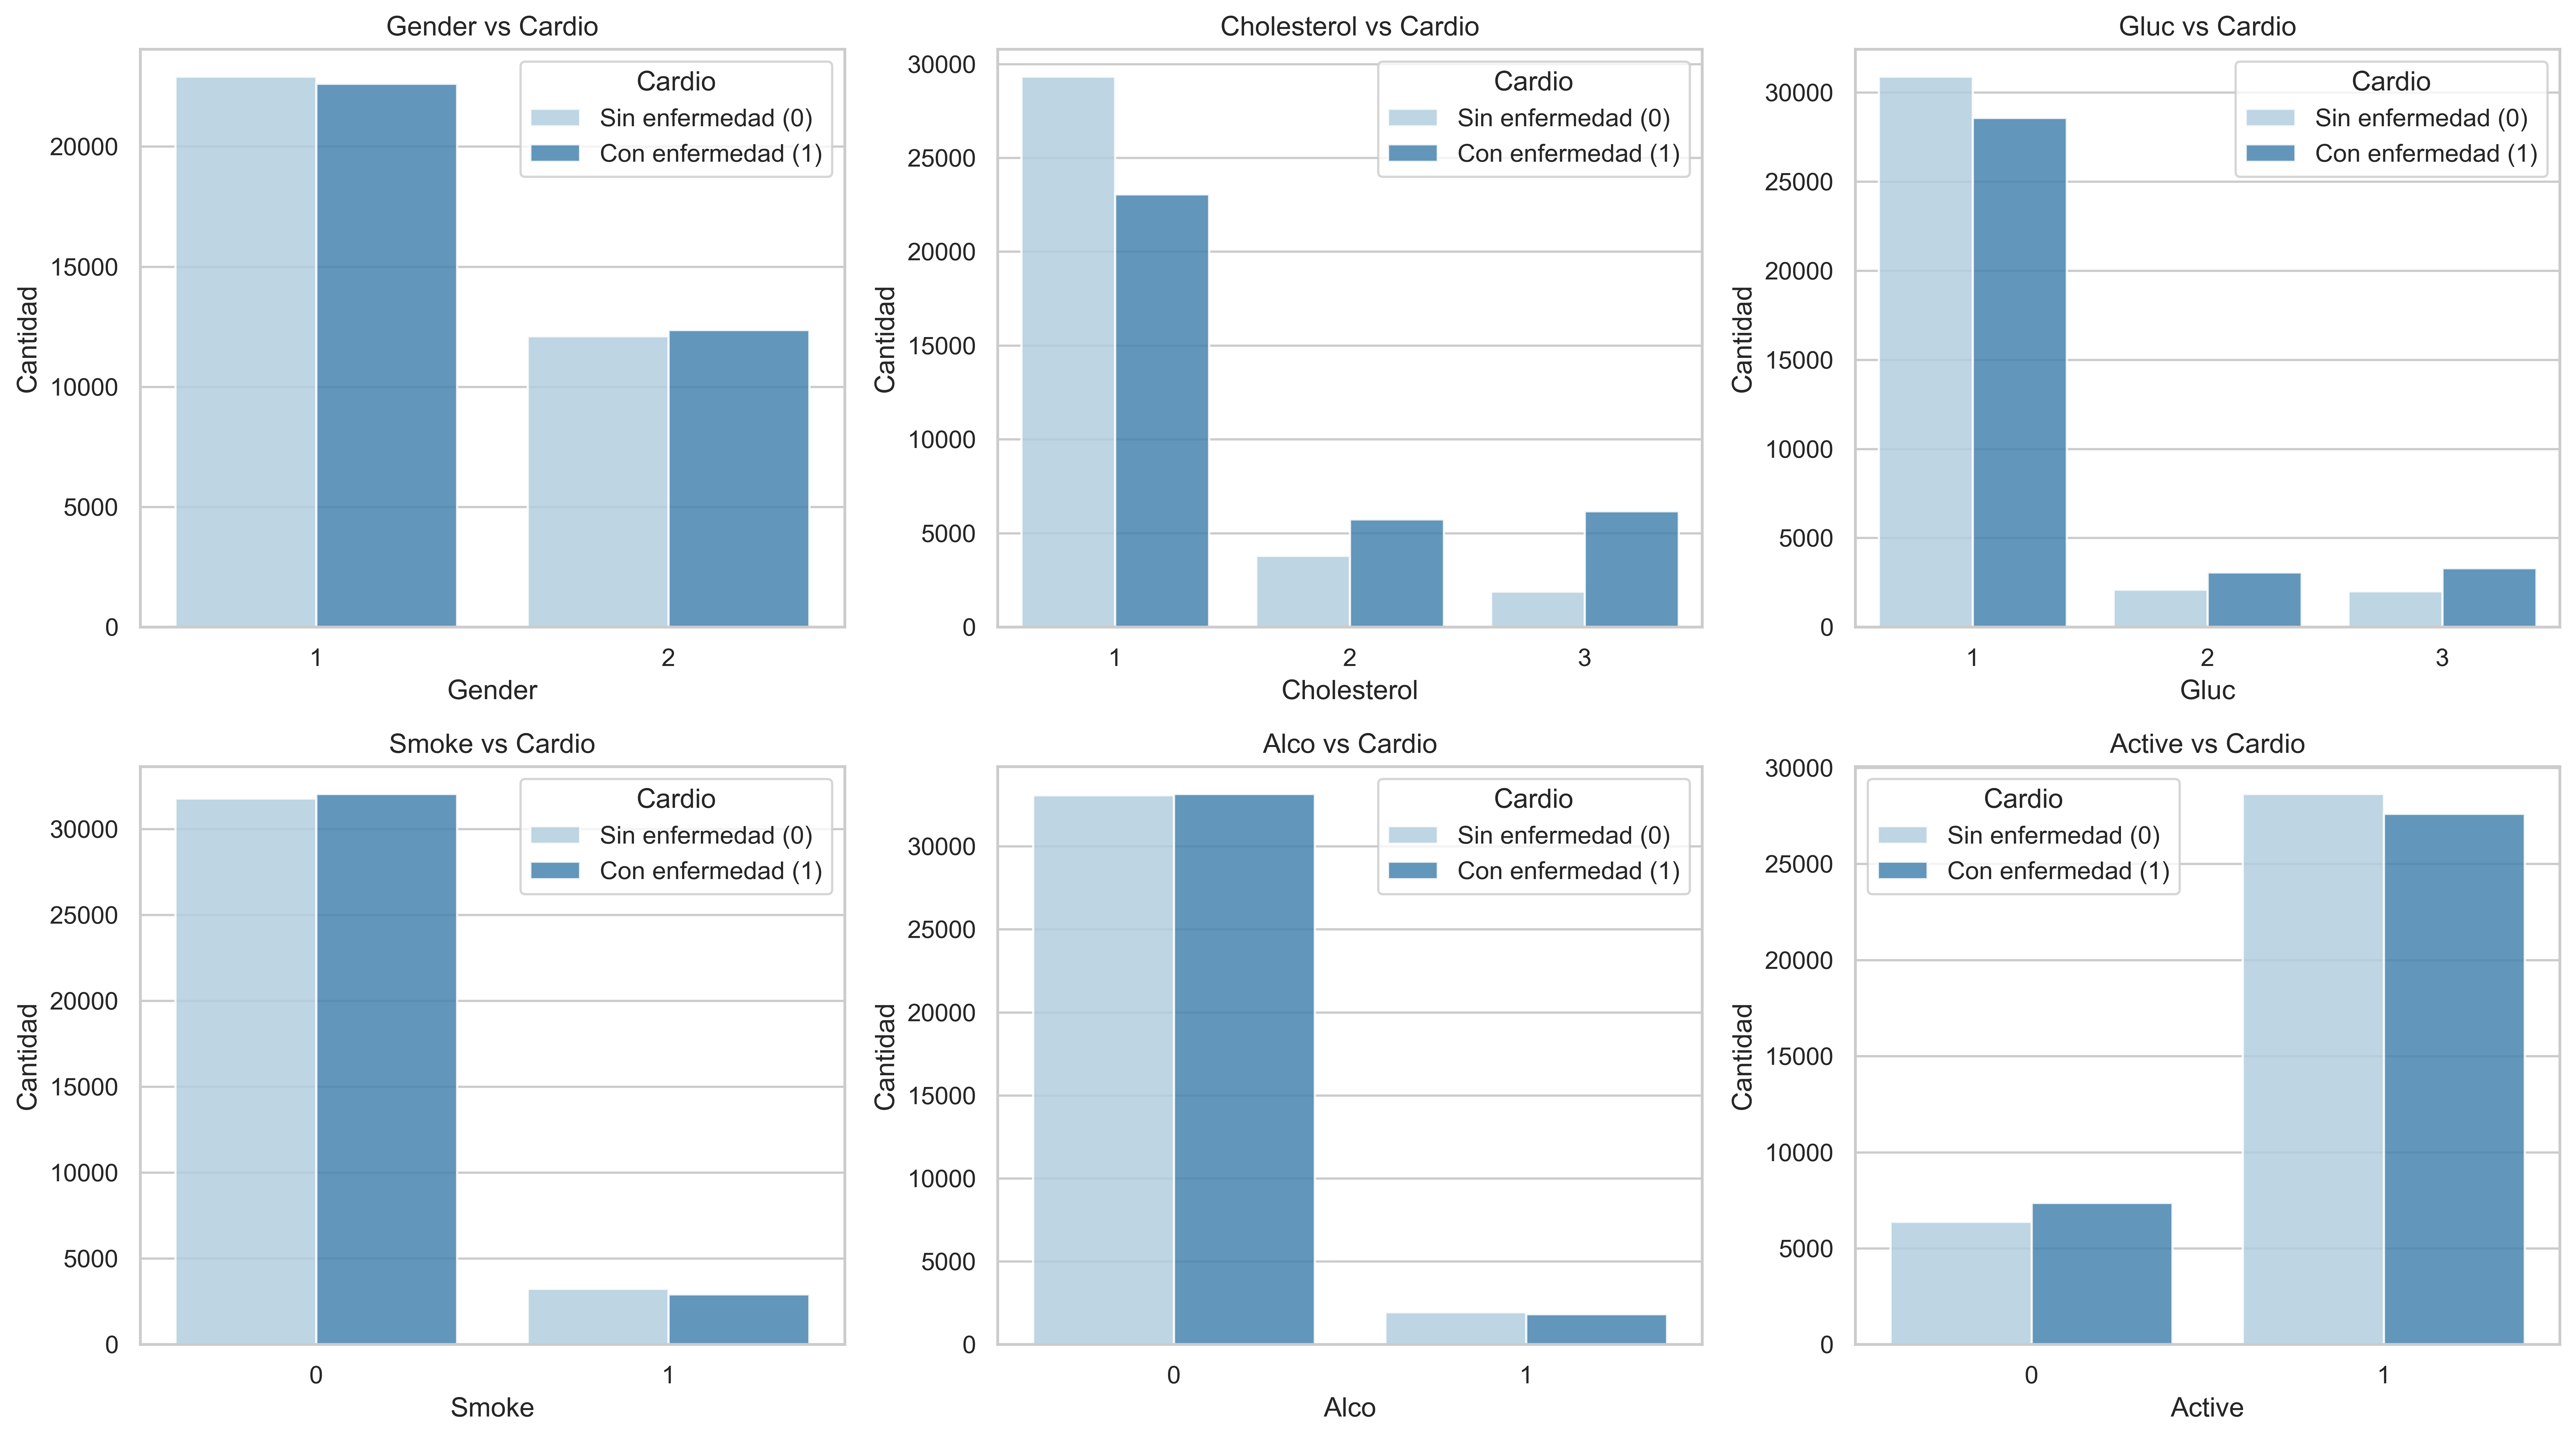

In [14]:
# Relación entre variables categoricas y la variable objetivo
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(variables_categoricas):
    sns.countplot(x=var, hue=variable_objetivo, data=df_plot, ax=axes[i], palette='Blues', alpha=0.85)
    axes[i].set_title(f'{var.capitalize()} vs {variable_objetivo.capitalize()}')
    axes[i].set_xlabel(var.capitalize())
    axes[i].set_ylabel('Cantidad')
    axes[i].legend(title='Cardio', labels=['Sin enfermedad (0)', 'Con enfermedad (1)'])

for j in range(len(variables_categoricas), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

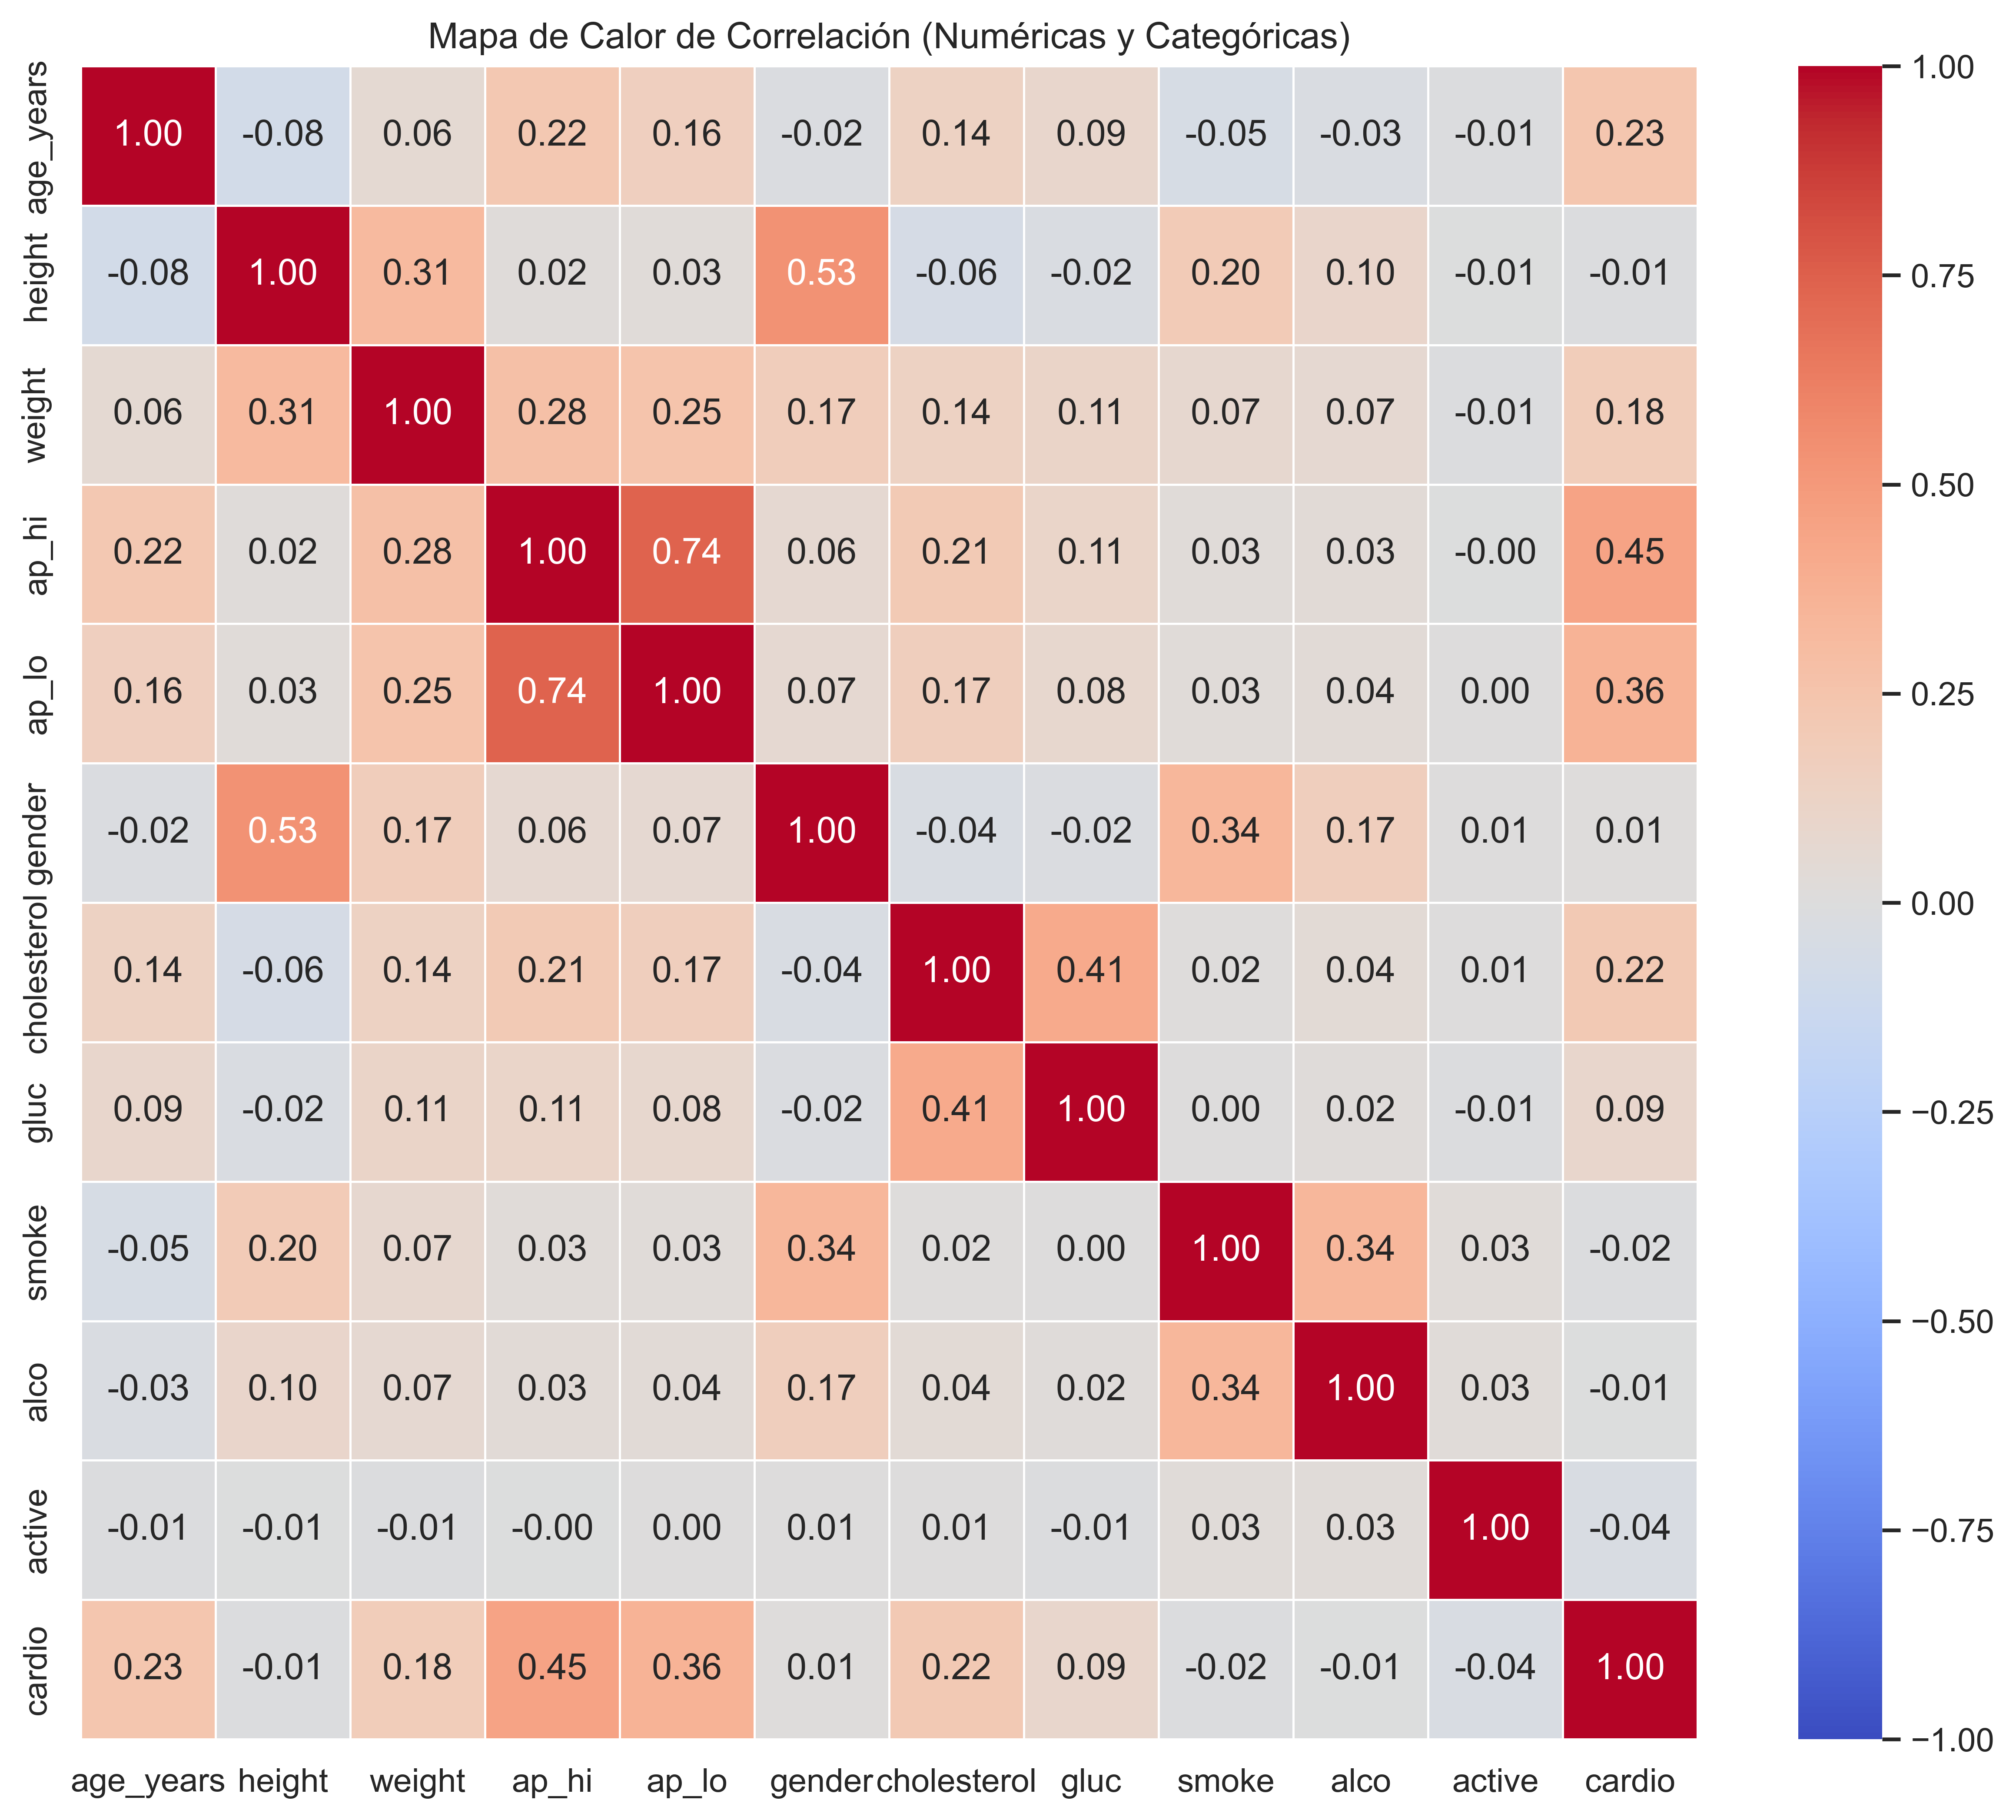

In [15]:
# Mapa de calor de correlación (numéricas + categóricas)
columnas_corr = variables_numericas + variables_categoricas + [variable_objetivo]
correlacion = df_plot[columnas_corr].corr(method='spearman')  # mejor para variables categóricas codificadas

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title('Mapa de Calor de Correlación (Numéricas y Categóricas)')
plt.show()
